In [7]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Robust repo root
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR   = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs"

print("Repo root  :", REPO_ROOT)
print("Data dir   :", DATA_DIR)
print("Output dir :", OUTPUT_DIR)
print()

# Verify all expected output files exist
expected = [
    "forward_routes.csv",
    "forward_kpi_summary.csv",
    "reverse_routes.csv",
    "reverse_kpi_summary.csv",
]
all_ok = True
for f in expected:
    path = OUTPUT_DIR / f
    status = "✅" if path.exists() else "❌ MISSING"
    print(f"  {status}  {f}")
    if not path.exists():
        all_ok = False

print()
print("All outputs present ✅" if all_ok else "⚠️  Some outputs missing — re-run pipeline notebooks first")

Repo root  : /Users/pranavt/Downloads/PGDBA/IIT KGP/SCA/project/SCA_DARK_STORES
Data dir   : /Users/pranavt/Downloads/PGDBA/IIT KGP/SCA/project/SCA_DARK_STORES/data
Output dir : /Users/pranavt/Downloads/PGDBA/IIT KGP/SCA/project/SCA_DARK_STORES/outputs

  ✅  forward_routes.csv
  ✅  forward_kpi_summary.csv
  ✅  reverse_routes.csv
  ✅  reverse_kpi_summary.csv

All outputs present ✅


In [8]:
fwd_kpi = pd.read_csv(OUTPUT_DIR / "forward_kpi_summary.csv")
rev_kpi = pd.read_csv(OUTPUT_DIR / "reverse_kpi_summary.csv")
master_df   = pd.read_parquet(DATA_DIR / "master_df_v2.parquet")
dark_stores = pd.read_csv(DATA_DIR / "dark_stores_final.csv")

print(f"Forward KPI zones : {len(fwd_kpi)}")
print(f"Reverse KPI zones : {len(rev_kpi)}")
print(f"Total orders      : {len(master_df):,}")
print(f"Dark stores       : {len(dark_stores)}")
print()
print(fwd_kpi.to_string(index=False))

Forward KPI zones : 11
Reverse KPI zones : 11
Total orders      : 19,207
Dark stores       : 11

 zone_id  n_customers  n_vehicles_used  total_dist_km  routing_cost_R$  max_route_km  min_route_km
       0           75                3         100.25           300.38         54.88         20.54
       1           75                3          84.52           276.78         34.04         17.18
       2           75                2         111.36           267.04         59.30         52.07
       3           75                2          97.90           246.85         67.55         30.35
       4           75                2          97.79           246.68         54.52         43.27
       5           75                2         108.10           262.15         63.47         44.63
       6           75                2          97.50           246.25         60.75         36.74
       7           75                3         100.23           300.35         35.10         31.86
       8    

In [9]:
# Merge on zone_id — use outer in case some zones only solved one direction
merged = fwd_kpi.merge(rev_kpi, on="zone_id", suffixes=("_fwd", "_rev"), how="outer")

print("=" * 70)
print("FORWARD vs REVERSE VRP — ZONE-LEVEL COMPARISON")
print("=" * 70)

display_cols = ["zone_id"]
for col in ["n_customers", "n_pickups", "n_vehicles_used_fwd", "n_vehicles_used_rev",
            "total_dist_km_fwd", "total_dist_km_rev",
            "routing_cost_R$_fwd", "routing_cost_R$_rev"]:
    if col in merged.columns:
        display_cols.append(col)

print(merged[display_cols].to_string(index=False))

print()
print("=" * 70)
print("TOTALS")
print("=" * 70)
fwd_dist  = fwd_kpi["total_dist_km"].sum()
rev_dist  = rev_kpi["total_dist_km"].sum()
fwd_cost  = fwd_kpi["routing_cost_R$"].sum()
rev_cost  = rev_kpi["routing_cost_R$"].sum()
fwd_vehs  = fwd_kpi["n_vehicles_used"].sum()
rev_vehs  = rev_kpi["n_vehicles_used"].sum()

print(f"  Forward  — {fwd_dist:.1f} km | R${fwd_cost:.0f} | {fwd_vehs} vehicles")
print(f"  Reverse  — {rev_dist:.1f} km | R${rev_cost:.0f} | {rev_vehs} vehicles")
print(f"  Combined — {fwd_dist+rev_dist:.1f} km | R${fwd_cost+rev_cost:.0f} | {fwd_vehs+rev_vehs} vehicles")
print("=" * 70)

FORWARD vs REVERSE VRP — ZONE-LEVEL COMPARISON
 zone_id  n_customers  n_pickups  n_vehicles_used_fwd  n_vehicles_used_rev  total_dist_km_fwd  total_dist_km_rev  routing_cost_R$_fwd  routing_cost_R$_rev
       0           75         25                    3                    2             100.25              59.98               300.38               189.97
       1           75         48                    3                    3              84.52              62.06               276.78               243.09
       2           75         31                    2                    3             111.36             462.39               267.04               843.58
       3           75         70                    2                    4              97.90            1137.74               246.85              1906.61
       4           75         19                    2                    2              97.79             190.34               246.68               385.51
       5           75  

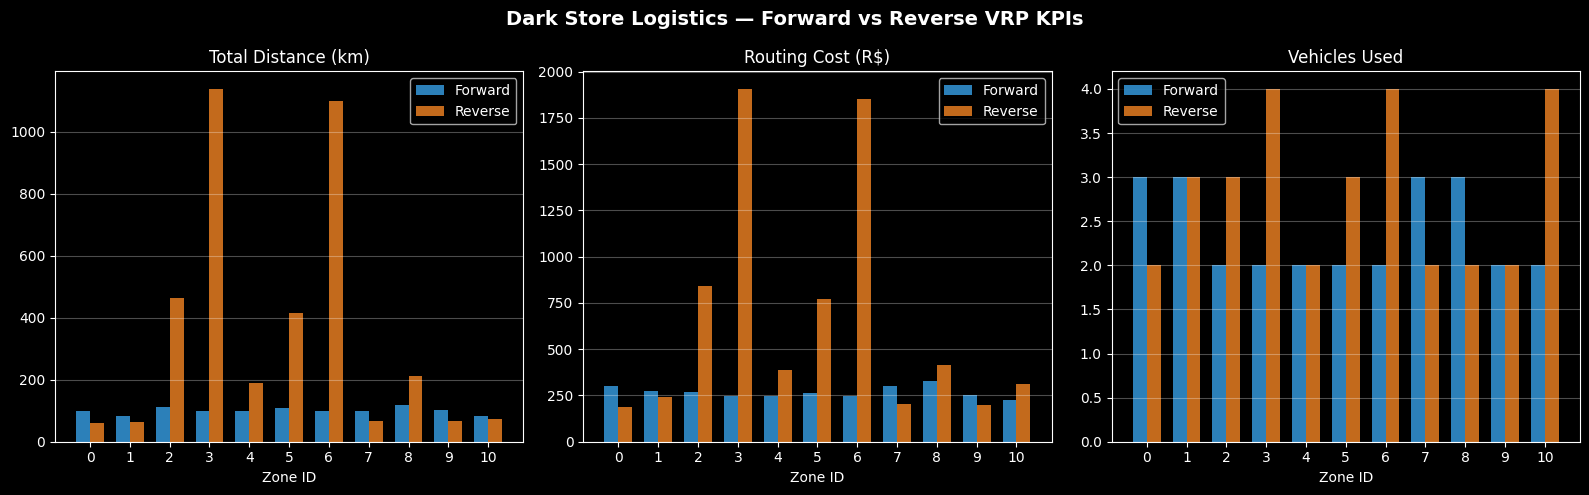

Saved: /Users/pranavt/Downloads/PGDBA/IIT KGP/SCA/project/SCA_DARK_STORES/outputs/fwd_vs_rev_kpi_charts.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dark Store Logistics — Forward vs Reverse VRP KPIs", fontsize=14, fontweight="bold")

zones = fwd_kpi["zone_id"].tolist()
x = range(len(zones))
width = 0.35

# Chart 1: Distance
ax = axes[0]
ax.bar([i - width/2 for i in x], fwd_kpi["total_dist_km"], width, label="Forward", color="#3498DB", alpha=0.85)
if "total_dist_km" in rev_kpi.columns:
    ax.bar([i + width/2 for i in x], rev_kpi.set_index("zone_id").reindex(zones)["total_dist_km"].fillna(0), width, label="Reverse", color="#E67E22", alpha=0.85)
ax.set_title("Total Distance (km)")
ax.set_xlabel("Zone ID")
ax.set_xticks(list(x))
ax.set_xticklabels(zones)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Chart 2: Cost
ax = axes[1]
ax.bar([i - width/2 for i in x], fwd_kpi["routing_cost_R$"], width, label="Forward", color="#3498DB", alpha=0.85)
if "routing_cost_R$" in rev_kpi.columns:
    ax.bar([i + width/2 for i in x], rev_kpi.set_index("zone_id").reindex(zones)["routing_cost_R$"].fillna(0), width, label="Reverse", color="#E67E22", alpha=0.85)
ax.set_title("Routing Cost (R$)")
ax.set_xlabel("Zone ID")
ax.set_xticks(list(x))
ax.set_xticklabels(zones)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Chart 3: Vehicles used
ax = axes[2]
ax.bar([i - width/2 for i in x], fwd_kpi["n_vehicles_used"], width, label="Forward", color="#3498DB", alpha=0.85)
if "n_vehicles_used" in rev_kpi.columns:
    ax.bar([i + width/2 for i in x], rev_kpi.set_index("zone_id").reindex(zones)["n_vehicles_used"].fillna(0), width, label="Reverse", color="#E67E22", alpha=0.85)
ax.set_title("Vehicles Used")
ax.set_xlabel("Zone ID")
ax.set_xticks(list(x))
ax.set_xticklabels(zones)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fwd_vs_rev_kpi_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'fwd_vs_rev_kpi_charts.png'}")

In [11]:
import folium

m = folium.Map(location=[-23.55, -46.63], zoom_start=11, tiles="CartoDB positron")

colors = ["red","blue","green","purple","orange","darkred","darkblue","darkgreen","cadetblue","darkpurple","black"]

for _, store in dark_stores.iterrows():
    zid = int(store["dark_store_id"])
    folium.CircleMarker(
        location=[store["lat"], store["lon"]],
        radius=12,
        color=colors[zid % len(colors)],
        fill=True, fill_opacity=0.9,
        tooltip=f"Dark Store {zid} | {store['n_orders']} orders | {store['coverage_5km_pct']}% coverage"
    ).add_to(m)

# Sample customer points (max 500 for perf)
sample = master_df.sample(min(500, len(master_df)), random_state=42)
for _, row in sample.iterrows():
    zid = int(row["dark_store_id"]) if "dark_store_id" in row else 0
    folium.CircleMarker(
        location=[row["customer_lat"], row["customer_lon"]],
        radius=2,
        color=colors[zid % len(colors)],
        fill=True, fill_opacity=0.4,
    ).add_to(m)

map_path = OUTPUT_DIR / "dark_store_coverage_map.html"
m.save(str(map_path))
print(f"Saved: {map_path}")
m

Saved: /Users/pranavt/Downloads/PGDBA/IIT KGP/SCA/project/SCA_DARK_STORES/outputs/dark_store_coverage_map.html


In [12]:
return_count = int(master_df["is_return_node"].sum()) if "is_return_node" in master_df.columns else "N/A"

print("=" * 65)
print("  DARK STORE LOGISTICS — FINAL PROJECT SUMMARY")
print("=" * 65)
print(f"  Dataset          : Olist Brazilian E-Commerce (São Paulo)")
print(f"  Total orders     : {len(master_df):,}")
print(f"  Dark stores (K)  : {len(dark_stores)}")
print(f"  Return nodes     : {return_count}")
print()
print(f"  FORWARD VRP")
print(f"    Total distance : {fwd_dist:.1f} km")
print(f"    Total cost     : R${fwd_cost:.0f}")
print(f"    Vehicles used  : {fwd_vehs}")
print(f"    Avg dist/zone  : {fwd_dist/len(fwd_kpi):.1f} km")
print()
print(f"  REVERSE VRP")
print(f"    Total distance : {rev_dist:.1f} km")
print(f"    Total cost     : R${rev_cost:.0f}")
print(f"    Vehicles used  : {rev_vehs}")
print(f"    Avg dist/zone  : {rev_dist/len(rev_kpi):.1f} km")
print()
print(f"  COMBINED")
print(f"    Total distance : {fwd_dist+rev_dist:.1f} km")
print(f"    Total cost     : R${fwd_cost+rev_cost:.0f}")
print(f"    Total vehicles : {fwd_vehs+rev_vehs}")
print("=" * 65)

  DARK STORE LOGISTICS — FINAL PROJECT SUMMARY
  Dataset          : Olist Brazilian E-Commerce (São Paulo)
  Total orders     : 19,207
  Dark stores (K)  : 11
  Return nodes     : 239

  FORWARD VRP
    Total distance : 1101.8 km
    Total cost     : R$2953
    Vehicles used  : 26
    Avg dist/zone  : 100.2 km

  REVERSE VRP
    Total distance : 3844.2 km
    Total cost     : R$7316
    Vehicles used  : 31
    Avg dist/zone  : 349.5 km

  COMBINED
    Total distance : 4946.1 km
    Total cost     : R$10269
    Total vehicles : 57
